In [ ]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [ ]:
from __future__ import print_function, division
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

# Импорт данных

In [ ]:
path = kagglehub.dataset_download(
    "gustavoachavez/architectural-styles-periods-dataset"
)
print("Kaggle cache path:", path)

destination_dir = "/data"

os.makedirs(destination_dir, exist_ok=True)

shutil.move(path, destination_dir)
print("Dataset moved to:", destination_dir)

Using Colab cache for faster access to the 'architectural-styles-periods-dataset' dataset.
Kaggle cache path: /kaggle/input/architectural-styles-periods-dataset


Error: Destination path '/data/architectural-styles-periods-dataset' already exists

# Приведение данных к удобному виду (без поддиректорий)

In [ ]:
!mv /data/1 /data/arch_dataset

mv: cannot stat '/data/1': No such file or directory


In [ ]:
!ls -al /data/arch_dataset

ls: cannot access '/data/arch_dataset': No such file or directory


In [ ]:
source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
os.makedirs(flat_root, exist_ok=True)

classes = os.listdir(source_root)

for class_name in classes:
    class_dir = os.path.join(flat_root, class_name)
    os.makedirs(class_dir, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png')

for class_name in classes:
    source_class_path = os.path.join(source_root, class_name)
    target_class_path = os.path.join(flat_root, class_name)

    print(f"Processing {class_name}...")

    count = 0
    for root, _, files in os.walk(source_class_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                src_file = os.path.join(root, file)
                dst_file = os.path.join(target_class_path, file)

                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)
                    count += 1

    print(f"  → {count} изображений скопировано в {class_name}")


Processing Eclecticism...
  → 1315 изображений скопировано в Eclecticism
Processing Neoclassicism...
  → 1225 изображений скопировано в Neoclassicism
Processing Baroque...
  → 1089 изображений скопировано в Baroque
Processing Modernism...
  → 1860 изображений скопировано в Modernism
Processing Revivalism...
  → 1919 изображений скопировано в Revivalism
Processing Renaissance_and_Colonialism...
  → 1294 изображений скопировано в Renaissance_and_Colonialism
Processing Classical...
  → 1022 изображений скопировано в Classical
Processing Early_Christian_Medieval...
  → 1338 изображений скопировано в Early_Christian_Medieval
Processing 21st_Century...
  → 1229 изображений скопировано в 21st_Century


# Визуализация дисбаланса в данных

In [ ]:
def count_images(main_root):
    counts = []
    for dirname in os.listdir(main_root):
        class_path = f'{main_root}/{dirname}'
        if os.path.isdir(class_path):
            total_files = sum(len(files) for _, _, files in os.walk(class_path))
            counts.append(total_files)
            print(f'{dirname}: {total_files}')
    return counts

In [ ]:
import pandas as pd

source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
classes = os.listdir(source_root)

styles_df = pd.DataFrame({
    'style': classes,
    'images': count_images(source_root) # [len(os.listdir(os.path.join(flat_root, cls))) for cls in classes]
})
styles_df

Eclecticism: 1315
Neoclassicism: 1225
Baroque: 1089
Modernism: 1860
Revivalism: 1919
Renaissance_and_Colonialism: 1294
Classical: 1022
Early_Christian_Medieval: 1338
21st_Century: 1229


,style,images
0,Eclecticism,1315
1,Neoclassicism,1225
2,Baroque,1089
3,Modernism,1860
4,Revivalism,1919
5,Renaissance_and_Colonialism,1294
6,Classical,1022
7,Early_Christian_Medieval,1338
8,21st_Century,1229


In [ ]:
import plotly.express as px

plot = px.bar(styles_df, x='style', y='images', title='Image count per style. Disbalance visualisation')
plot.show()

# Разделение на тренировочную, валидационную и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split
import random

for split in ['train', 'val', 'test']:
    split_path = os.path.join(flat_root, split)
    os.makedirs(split_path, exist_ok=True)

random.seed(42)

print("Splitting classes...")
for class_name in classes:
    print(f"  {class_name}...")

    class_path = os.path.join(flat_root, class_name)
    files = os.listdir(class_path)

    train_files, temp_files = train_test_split(files, train_size=0.8, random_state=42)
    val_files, test_files = train_test_split(temp_files, train_size=0.5, random_state=42)

    for split_name, split_files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        src_dir = class_path
        dst_dir = os.path.join(flat_root, split_name, class_name)
        os.makedirs(dst_dir, exist_ok=True)

        for file in split_files:
            shutil.move(os.path.join(src_dir, file), os.path.join(dst_dir, file))

    print(f"    → train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

    if not os.listdir(class_path):
        os.rmdir(class_path)
        print(f"Deleted empty dir: {class_name}")

Splitting classes...
  Eclecticism...
    → train: 1052, val: 131, test: 132
Deleted empty dir: Eclecticism
  Neoclassicism...
    → train: 980, val: 122, test: 123
Deleted empty dir: Neoclassicism
  Baroque...
    → train: 871, val: 109, test: 109
Deleted empty dir: Baroque
  Modernism...
    → train: 1488, val: 186, test: 186
Deleted empty dir: Modernism
  Revivalism...
    → train: 1535, val: 192, test: 192
Deleted empty dir: Revivalism
  Renaissance_and_Colonialism...
    → train: 1035, val: 129, test: 130
Deleted empty dir: Renaissance_and_Colonialism
  Classical...
    → train: 817, val: 102, test: 103
Deleted empty dir: Classical
  Early_Christian_Medieval...
    → train: 1070, val: 134, test: 134
Deleted empty dir: Early_Christian_Medieval
  21st_Century...
    → train: 983, val: 123, test: 123
Deleted empty dir: 21st_Century


# Преобразование данных в тензоры + аугментация

In [ ]:
# Make transforms and use data loaders # We'll use these a lot, so make them variables
mean_nums = [0.485, 0.456, 0.406]
std_nums = [0.229, 0.224, 0.225]
chosen_transforms = {'train': transforms.Compose([ transforms.RandomResizedCrop(size=256), transforms.RandomRotation(degrees=15), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean_nums, std_nums) ]), 'val': transforms.Compose([ transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(mean_nums, std_nums) ]), 'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean_nums, std_nums)
    ])}

In [ ]:
data_dir = flat_root

chosen_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), chosen_transforms[x]) for x in ['train', 'val', 'test']}

In [ ]:
dataloaders = {x: torch.utils.data.DataLoader(chosen_datasets[x], batch_size=4, shuffle=(x == 'train'), num_workers=4) for x in ['train', 'val', 'test']}

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



In [ ]:
dataset_sizes = {x: len(chosen_datasets[x]) for x in ['train', 'val', 'test']}
class_names = chosen_datasets['train'].classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(dataset_sizes, class_names, device)

{'train': 9831, 'val': 1228, 'test': 1232} ['21st_Century', 'Baroque', 'Classical', 'Early_Christian_Medieval', 'Eclecticism', 'Modernism', 'Neoclassicism', 'Renaissance_and_Colonialism', 'Revivalism'] cuda


In [ ]:
# Visualize some images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array(mean_nums)
    std = np.array(std_nums)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    #plt.pause(0.001)

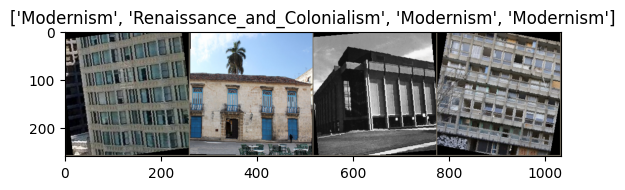

In [ ]:
# Grab some of the training data to visualize
inputs, classes = next(iter(dataloaders['train']))
# Now we construct a grid from batch
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [ ]:
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

# wide_model = models.resnet18(weights='IMAGENET1K_V1')
wide_model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in wide_model.parameters():
    param.requires_grad = False
# num_ftrs = wide_model.fc.in_features
num_ftrs = wide_model.classifier[1].in_features
num_ftrs

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 85.3MB/s]


1280

In [ ]:
wide_model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 9)
)

wide_model = wide_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_wide = torch.optim.SGD(
    filter(lambda p: p.requires_grad, wide_model.parameters()),
    lr=0.001,
    momentum=0.9
)
exp_lr_scheduler_wide = lr_scheduler.StepLR(optimizer_wide, step_size=7, gamma=0.1)

In [ ]:
wide_model_trained, metrics_wide = train_model(
    wide_model,
    criterion,
    optimizer_wide,
    exp_lr_scheduler_wide,
    dataloaders,
    dataset_sizes,
    num_epochs=25)

Epoch 1/25
----------
Iterating through data...
train Loss: 2.0983 | Acc: 0.2249 | Weighted Acc: 0.0733 | F1-macro: 0.1350 | Top-1 Acc: 0.2249 | Top-3 Acc: 0.5204
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



val Loss: 1.9851 | Acc: 0.3135 | Weighted Acc: 0.1603 | F1-macro: 0.2012 | Top-1 Acc: 0.3135 | Top-3 Acc: 0.7028
Epoch Time: 152.8699s

Epoch 2/25
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



train Loss: 1.8636 | Acc: 0.3619 | Weighted Acc: 0.2338 | F1-macro: 0.3038 | Top-1 Acc: 0.3619 | Top-3 Acc: 0.6995
Iterating through data...


...

val Loss: 1.2120 | Acc: 0.5847 | Weighted Acc: 0.5236 | F1-macro: 0.5774 | Top-1 Acc: 0.5847 | Top-3 Acc: 0.8673
Epoch Time: 146.6018s

Epoch 25/25
----------
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



train Loss: 1.3052 | Acc: 0.5394 | Weighted Acc: 0.4768 | F1-macro: 0.5298 | Top-1 Acc: 0.5394 | Top-3 Acc: 0.8407
Iterating through data...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



val Loss: 1.2103 | Acc: 0.5896 | Weighted Acc: 0.5328 | F1-macro: 0.5863 | Top-1 Acc: 0.5896 | Top-3 Acc: 0.8656
Epoch Time: 146.2328s

Training complete in 61m 28s
Best val Weighted Acc: 0.532791 | Best F1-score: 0.5863 | Best Top-1 Acc: 0.5896 | Best Top-3 Acc: 0.8689


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



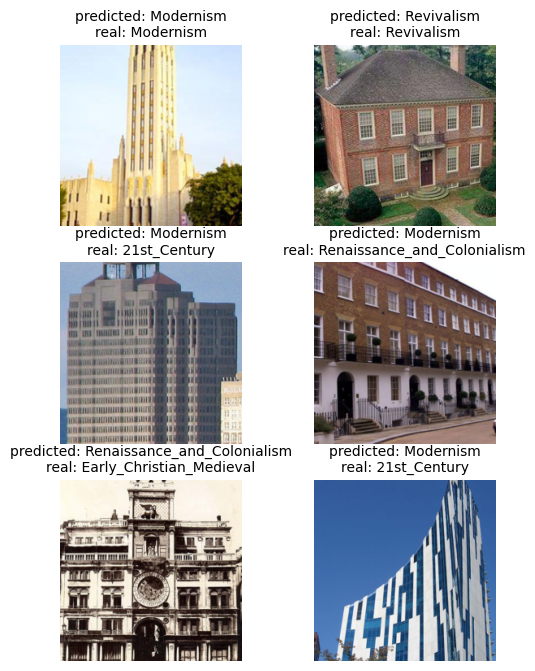

In [24]:
visualize_model(wide_model_trained, num_images=6, class_names=class_names, vis_loader=vis_loader)

In [25]:
def visualize_metrics1(metrics, title, epochs=25):
    x = list(range(1, epochs + 1))
    accuracy_train, f1_train, top3_train, top1_train, loss_train, accuracy_val, f1_val, top3_val, top1_val, loss_val = metrics

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=("Weighted accuracy", "F1-score macro", "Top-3 Accuracy", "Top-1 Accuracy", "Top-1 vs Top-3 Validation Accuracy", "Loss function"),
        horizontal_spacing=0.08,
        vertical_spacing=0.2)

    # Accuracy (1,1) — своя легенда "legend1"
    fig.add_trace(go.Scatter(x=x, y=accuracy_train, name='train',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)
    fig.add_trace(go.Scatter(x=x, y=accuracy_val, name='val',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)

    # F1 (1,2) — своя легенда "legend2"
    fig.add_trace(go.Scatter(x=x, y=f1_train, name='train',
                             legend="legend2", legendgroup="f1"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x, y=f1_val, name='val',
                             legend="legend2", legendgroup="f1"), row=1, col=2)

    # Top-3 (1,3) — "legend3"
    fig.add_trace(go.Scatter(x=x, y=top3_train, name='train',
                             legend="legend3", legendgroup="top3"), row=1, col=3)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='val',
                             legend="legend3", legendgroup="top3"), row=1, col=3)

    # Top-1 (2,1) — "legend4"
    fig.add_trace(go.Scatter(x=x, y=top1_train, name='train',
                             legend="legend4", legendgroup="top1"), row=2, col=1)
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='val',
                             legend="legend4", legendgroup="top1"), row=2, col=1)

    # vs (2,2) - "legend5"
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='train',
                             legend="legend5", legendgroup="vs"), row=2, col=2)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='val',
                             legend="legend5", legendgroup="vs"), row=2, col=2)

    # Loss (2,3) — "legend6"
    fig.add_trace(go.Scatter(x=x, y=loss_train, name='train',
                             legend="legend6", legendgroup="loss"), row=2, col=3)
    fig.add_trace(go.Scatter(x=x, y=loss_val, name='val',
                             legend="legend6", legendgroup="loss"), row=2, col=3)

    for i in range(1, 3):
        for j in range(1, 4):
            fig.update_xaxes(title_text="Epoch", row=i, col=j)
            fig.update_yaxes(title_text="Metric value", row=i, col=j)

    fig.update_layout(title_text=title, height=800, width=1200,
                      legend1=dict(x=0.2, y=0.7, xanchor="left", yanchor="top"),
                      legend2=dict(x=0.63, y=0.7, xanchor="right", yanchor="top"),
                      legend3=dict(x=0.95, y=0.62, xanchor="left", yanchor="bottom"),
                      legend4=dict(x=0.28, y=0.01, xanchor="right", yanchor="bottom"),
                      legend5=dict(x=0.63, y=0.00, xanchor="right", yanchor="bottom"),
                      legend6=dict(x=0.99, y=0.3, xanchor="right", yanchor="bottom"),
                      dragmode="pan",)
    fig.show()

In [27]:
# Сначала импортируем необходимые библиотеки
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def visualize_metrics1(metrics, title, epochs=25):
    x = list(range(1, epochs + 1))
    accuracy_train, f1_train, top3_train, top1_train, loss_train, accuracy_val, f1_val, top3_val, top1_val, loss_val = metrics

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=("Weighted accuracy", "F1-score macro", "Top-3 Accuracy", "Top-1 Accuracy", "Top-1 vs Top-3 Validation Accuracy", "Loss function"),
        horizontal_spacing=0.08,
        vertical_spacing=0.2)

    # Accuracy (1,1) — своя легенда "legend1"
    fig.add_trace(go.Scatter(x=x, y=accuracy_train, name='train',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)
    fig.add_trace(go.Scatter(x=x, y=accuracy_val, name='val',
                             legend="legend1", legendgroup="acc1"), row=1, col=1)

    # F1 (1,2) — своя легенда "legend2"
    fig.add_trace(go.Scatter(x=x, y=f1_train, name='train',
                             legend="legend2", legendgroup="f1"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x, y=f1_val, name='val',
                             legend="legend2", legendgroup="f1"), row=1, col=2)

    # Top-3 (1,3) — "legend3"
    fig.add_trace(go.Scatter(x=x, y=top3_train, name='train',
                             legend="legend3", legendgroup="top3"), row=1, col=3)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='val',
                             legend="legend3", legendgroup="top3"), row=1, col=3)

    # Top-1 (2,1) — "legend4"
    fig.add_trace(go.Scatter(x=x, y=top1_train, name='train',
                             legend="legend4", legendgroup="top1"), row=2, col=1)
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='val',
                             legend="legend4", legendgroup="top1"), row=2, col=1)

    # vs (2,2) - "legend5" — исправлено: правильные названия для легенды
    fig.add_trace(go.Scatter(x=x, y=top1_val, name='Top-1',
                             legend="legend5", legendgroup="vs"), row=2, col=2)
    fig.add_trace(go.Scatter(x=x, y=top3_val, name='Top-3',
                             legend="legend5", legendgroup="vs"), row=2, col=2)

    # Loss (2,3) — "legend6"
    fig.add_trace(go.Scatter(x=x, y=loss_train, name='train',
                             legend="legend6", legendgroup="loss"), row=2, col=3)
    fig.add_trace(go.Scatter(x=x, y=loss_val, name='val',
                             legend="legend6", legendgroup="loss"), row=2, col=3)

    for i in range(1, 3):
        for j in range(1, 4):
            fig.update_xaxes(title_text="Epoch", row=i, col=j)
            fig.update_yaxes(title_text="Metric value", row=i, col=j)

    fig.update_layout(title_text=title, height=800, width=1200,
                      legend1=dict(x=0.2, y=0.7, xanchor="left", yanchor="top"),
                      legend2=dict(x=0.63, y=0.7, xanchor="right", yanchor="top"),
                      legend3=dict(x=0.95, y=0.62, xanchor="left", yanchor="bottom"),
                      legend4=dict(x=0.28, y=0.01, xanchor="right", yanchor="bottom"),
                      legend5=dict(x=0.63, y=0.00, xanchor="right", yanchor="bottom"),
                      legend6=dict(x=0.99, y=0.3, xanchor="right", yanchor="bottom"),
                      dragmode="pan",)
    fig.show()

In [28]:
visualize_metrics1(metrics_wide, "Metics: Wide", 25)

In [29]:
torch.save(wide_model_trained.state_dict(), 'wide_head_model.pt')